# 构建BCC模型

In [1]:
def generate_bcc_structure_with_composition(lattice_constant, supercell_size, max_allowed_coordinate, random_seed=None):
    if random_seed is not None:
        random.seed(random_seed)
    num_cells = int(supercell_size / lattice_constant) + 1

    corner_atoms = [(0, 0, 0)]
    body_atoms = [(0.5, 0.5, 0.5)]

    atoms_pos = []

    # Step 1: 生成所有原子位置（corner + body center）
    for x in range(num_cells):
        for y in range(num_cells):
            for z in range(num_cells):
                for dx, dy, dz in corner_atoms + body_atoms:
                    atom_x = x * lattice_constant + dx * lattice_constant
                    atom_y = y * lattice_constant + dy * lattice_constant
                    atom_z = z * lattice_constant + dz * lattice_constant
                    if 0 <= atom_x <= max_allowed_coordinate and \
                       0 <= atom_y <= max_allowed_coordinate and \
                       0 <= atom_z <= max_allowed_coordinate:
                        atoms_pos.append((round(atom_x, 3), round(atom_y, 3), round(atom_z, 3)))

    atoms_pos = list(set(atoms_pos))
    total_atoms = len(atoms_pos)
    # Step 2: 给定成分比例
    composition_ratio = {
        0: 0.56,  # Ti
        1: 0.3,   # Zr
        2: 0.14   # Nb
    }

    element_counts = {k: int(v * total_atoms) for k, v in composition_ratio.items()}

    diff = total_atoms - sum(element_counts.values())
    if diff > 0:
        max_key = max(composition_ratio, key=composition_ratio.get)
        element_counts[max_key] += diff

    element_types = []
    for k in sorted(element_counts):
        element_types.extend([k] * element_counts[k])

    random.shuffle(element_types)

    atoms = np.array([
        [x, y, z, t]
        for (x, y, z), t in zip(atoms_pos, element_types)
    ])
    return atoms

# 构建NbNb化学偏好排列型SRO

In [2]:
import numpy as np
import random

def generate_bcc_sro_structure_nb(
    lattice_constant,
    supercell_size,
    max_allowed_coordinate,
    composition_case,
    sro_mode,
    random_seed=42):

    np.random.seed(random_seed)
    random.seed(random_seed)

    # 提高 Nb 含量的组合方案
    composition_cases = {
    1: {"Ti": 0.40, "Zr": 0.20, "Nb": 0.40},  # Nb 40%
    2: {"Ti": 0.35, "Zr": 0.20, "Nb": 0.45},  # Nb 45%
    3: {"Ti": 0.30, "Zr": 0.20, "Nb": 0.50},  # Nb 50%
    4: {"Ti": 0.25, "Zr": 0.25, "Nb": 0.50},  # Nb 50%
}

    if composition_case not in composition_cases:
        raise ValueError("Invalid composition_case")

    comp = composition_cases[composition_case]

    num_cells = int(supercell_size / lattice_constant) + 1

    # 构建 BCC 原子坐标
    corner_atoms = [(0, 0, 0)]
    body_atoms = [(0.5, 0.5, 0.5)]
    atoms_pos = []

    for x in range(num_cells):
        for y in range(num_cells):
            for z in range(num_cells):
                for dx, dy, dz in corner_atoms + body_atoms:
                    atom_x = round(x * lattice_constant + dx * lattice_constant, 5)
                    atom_y = round(y * lattice_constant + dy * lattice_constant, 5)
                    atom_z = round(z * lattice_constant + dz * lattice_constant, 5)
                    if atom_x <= max_allowed_coordinate and atom_y <= max_allowed_coordinate and atom_z <= max_allowed_coordinate:
                        atoms_pos.append((atom_x, atom_y, atom_z))

    atoms_pos = list(set(atoms_pos))
    total_atoms = len(atoms_pos)

    # 元素总数
    element_counts = {el: int(ratio * total_atoms) for el, ratio in comp.items()}
    diff = total_atoms - sum(element_counts.values())
    element_counts["Ti"] += diff  # 修正误差

    # 元素映射
    element_map = {"Ti": 0, "Zr": 1, "Nb": 2}
    elements_list = [None] * total_atoms

    # 生成 Nb 的偏聚索引
    if sro_mode == 1:
        # 模式1: 沿对角线方向 x+y+z 偏聚 Nb
        atoms_pos_sorted = sorted(enumerate(atoms_pos), key=lambda x: x[1][0] + x[1][1] + x[1][2])
        nb_indices = [idx for idx, _ in atoms_pos_sorted[:element_counts["Nb"]]]

    elif sro_mode == 2:
        # 模式2: slab 模式，选择 x 最大的 slab 富集 Nb
        atoms_pos_sorted = sorted(enumerate(atoms_pos), key=lambda x: x[1][0], reverse=True)
        nb_indices = [idx for idx, _ in atoms_pos_sorted[:element_counts["Nb"]]]

    elif sro_mode == 3:
        # 模式3: 空间聚集 Nb - 最靠近某一点（如 corner）的一群原子
        corner = np.array([0.0, 0.0, 0.0])
        atoms_pos_sorted = sorted(enumerate(atoms_pos), key=lambda x: np.linalg.norm(np.array(x[1]) - corner))
        nb_indices = [idx for idx, _ in atoms_pos_sorted[:element_counts["Nb"]]]

    elif sro_mode == 4:
        # 模式4: 核壳结构，中心为 Nb
        center = np.mean(atoms_pos, axis=0)
        atoms_pos_sorted = sorted(enumerate(atoms_pos), key=lambda x: np.linalg.norm(np.array(x[1]) - center))
        nb_indices = [idx for idx, _ in atoms_pos_sorted[:element_counts["Nb"]]]

    else:
        raise ValueError("Invalid sro_mode. Use 1~4.")

    # 其余索引分配 Ti/Zr
    remaining_indices = list(set(range(total_atoms)) - set(nb_indices))
    ti_count = element_counts["Ti"]
    zr_count = element_counts["Zr"]
    random.shuffle(remaining_indices)

    for idx in nb_indices:
        elements_list[idx] = "Nb"

    for idx in remaining_indices:
        if ti_count > 0:
            elements_list[idx] = "Ti"
            ti_count -= 1
        elif zr_count > 0:
            elements_list[idx] = "Zr"
            zr_count -= 1
        else:
            elements_list[idx] = "Ti"  # fallback

    # 转为整数 ID
    element_ids = [element_map[el] for el in elements_list]

    # 输出 array
    atoms = np.array([[pos[0], pos[1], pos[2], el] for pos, el in zip(atoms_pos, element_ids)])
    return atoms


In [3]:
import numpy as np
import pandas as pd
import math

# Given parameters
N_1NN = 8           # BCC structure: 12 first nearest neighbors
eta = 0.5            # detection efficiency
lambda_1 = N_1NN * eta  # expected number of detected 1NNs

# Maximum m to calculate (APT mNN up to m = 20)
max_m = 20

# Compute P(k; lambda) for k = 0 to (max_m)
P_k = [math.exp(-lambda_1) * (lambda_1 ** k) / math.factorial(k) for k in range(max_m + 1)]

# Compute cumulative probabilities P_>=m
P_ge_m = []
for m in range(1, max_m + 1):
    cumulative = sum(P_k[:m])
    P_ge = 1 - cumulative
    P_ge_m.append(P_ge)

# Build the table
df = pd.DataFrame({
    "APT mNN (m)": list(range(1, max_m + 1)),
    "P(≥m; λ=6)": P_ge_m
})
df.head(20)  # Show the full 20-row table

,APT mNN (m),P(≥m; λ=6)
0,1,9.816844e-01
1,2,9.084218e-01
2,3,7.618967e-01
3,4,5.665299e-01
4,5,3.711631e-01
5,6,2.148696e-01
6,7,1.106740e-01
7,8,5.113362e-02
8,9,2.136343e-02
9,10,8.132243e-03


In [4]:
def add_data_noise(data_reconstruction, mu,  sigma_xy, sigma_z, plot_noise):
    row = data_reconstruction.shape[0]
    noise_xy = np.random.normal(mu, sigma_xy, [row ,2]) 
    noise_z = np.random.normal(mu, sigma_z, [row ,1])
    zeros = np.zeros((row, 1))
    noise = np.hstack((noise_xy, noise_z))
    noise = np.hstack((noise_xy, noise_z, zeros))


    data_noise = data_reconstruction + noise
    # print(data_noise.type)
    # Plot 3D crystal structure with noise
    if plot_noise == True:
        ax = plt.subplot(111, projection='3d')  # build a project
        ax.scatter(data_noise [:, 0], data_noise [:, 1], data_noise [:, 2], 
                   c=data_noise [:, 3], s=8)  # 绘制数据点
        ax.tick_params(axis='both', which='major', labelsize=16)
        ax.set_zlabel('Z', fontsize=16)  # axis
        ax.set_ylabel('Y', fontsize=16)
        ax.set_xlabel('X', fontsize=16)
        plt.show()
    return data_noise

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import spatial
import pandas as pd
import random as rd
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator
from fast_histogram import histogram2d as fast_histogram2d 
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import math
import random
import shutil

In [6]:
def simulate_detection_efficiency(data, detect_eff, plot_effiency):
    row = data.shape[0]
    idx = rd.sample(range(row),row)
    data_shuffle = data[idx]
    data_sample = data_shuffle[:int(row*detect_eff), :]
    if plot_effiency == True:
        ax = plt.subplot(111, projection='3d')  # build a project
        ax.scatter( data_sample [:, 0],  data_sample [:, 1],  data_sample [:, 2], 
                   c= data_sample [:, 3], s=8)  # 绘制数据点
        ax.tick_params(axis='both', which='major', labelsize=16)
        ax.set_zlabel('Z', fontsize=16)  # axis
        ax.set_ylabel('Y', fontsize=16)
        ax.set_xlabel('X', fontsize=16)
        plt.show()
    return data_sample

In [7]:
from itertools import product
from collections import defaultdict

xystd_list = np.arange(0.2, 0.51, 0.1)
zstd_list = np.arange(0.02, 0.051, 0.01)
detect_eff_list = np.arange(0.4, 0.71, 0.1)

num_samples_per_case = 4  # 每种 (composition_case, sro_mode) 下生成多少样本

composition_cases = list(range(1, 5))  
sro_modes = list(range(1, 5))          # 1 ~ 5

sro_data_all = []
bcc_data_all = []

for sigma_xy, sigma_z, eta in product(xystd_list, zstd_list, detect_eff_list):
    sro_sample_count = 0
    
    # -------- 生成 SRO 数据 ----------
    for composition_case, sro_mode in product(composition_cases, sro_modes):
        for _ in range(num_samples_per_case):
            sro_atoms = generate_bcc_sro_structure_nb(
                lattice_constant=0.33,
                supercell_size=0.99,
                max_allowed_coordinate=0.99,
                composition_case=composition_case,
                sro_mode=sro_mode  # <- 确保此参数在函数中被处理
            )
            noisy_sro = add_data_noise(
                sro_atoms, mu=0, sigma_xy=sigma_xy, sigma_z=sigma_z, plot_noise=False
            )
            detected_sro = simulate_detection_efficiency(
                noisy_sro, detect_eff=eta, plot_effiency=False
            )
            sro_data_all.append({
                'sigma_xy': sigma_xy,
                'sigma_z': sigma_z,
                'detect_eff': eta,
                'composition_case': composition_case,
                'sro_mode': sro_mode,
                'data': detected_sro
            })
            sro_sample_count += 1

    # -------- 生成对应数量的 BCC 数据 ----------
    for _ in range(sro_sample_count):
        bcc_atoms = generate_bcc_structure_with_composition(
            lattice_constant=0.33,
            supercell_size=0.99,
            max_allowed_coordinate=0.99
        )
        noisy_bcc = add_data_noise(
            bcc_atoms, mu=0, sigma_xy=sigma_xy, sigma_z=sigma_z, plot_noise=False
        )
        detected_bcc = simulate_detection_efficiency(
            noisy_bcc, detect_eff=eta, plot_effiency=False
        )
        bcc_data_all.append({
            'sigma_xy': sigma_xy,
            'sigma_z': sigma_z,
            'detect_eff': eta,
            'data': detected_bcc
        })

# ✅ 汇总打印
print(f"✅ 总 SRO 数据组数：{len(sro_data_all)}")
print(f"✅ 总 BCC 数据组数：{len(bcc_data_all)}")

✅ 总 SRO 数据组数：4096
✅ 总 BCC 数据组数：4096


In [8]:
def calculate_targeted_sro_pairs(
    data,
    voxel_bounds,
    voxel_center,
    r_core,
    P_ge_m,
    structure_type_global,
    element_fractions,
    target_pairs
):
    max_m_used = sum(p >= 0.01 for p in P_ge_m)
    valid_weights = P_ge_m[:max_m_used]

    tree = KDTree(data[:, :3])
    sro_dict_list = []

    for i in range(len(data)):
        pos = data[i, :3]
        if np.linalg.norm(pos - voxel_center) > r_core:
            continue

        if not all([
            voxel_bounds[0][0] <= pos[0] <= voxel_bounds[0][1],
            voxel_bounds[1][0] <= pos[1] <= voxel_bounds[1][1],
            voxel_bounds[2][0] <= pos[2] <= voxel_bounds[2][1]
        ]):
            continue

        center_type = int(data[i, 3])
        distances, indices = tree.query(pos, k=max_m_used + 1)
        neighbor_indices = [j for j in indices if j != i]

        neighbor_types = []
        applied_weights = []

        for rel_idx, j in enumerate(neighbor_indices):
            if rel_idx >= len(valid_weights):
                break

            neighbor_pos = data[j, :3]
            if not all([
                voxel_bounds[0][0] <= neighbor_pos[0] <= voxel_bounds[0][1],
                voxel_bounds[1][0] <= neighbor_pos[1] <= voxel_bounds[1][1],
                voxel_bounds[2][0] <= neighbor_pos[2] <= voxel_bounds[2][1]
            ]):
                continue

            neighbor_types.append(int(data[j, 3]))
            applied_weights.append(valid_weights[rel_idx])

        if len(applied_weights) == 0:
            sro_result = {
                "xyz": tuple(pos),
                "atom_type": center_type,
                "sro_values": {f"{a}-{b}": np.nan for (a, b) in target_pairs},
                "structure_type": structure_type_global
            }
            sro_dict_list.append(sro_result)
            continue

        weighted_counts = {}
        for t, w in zip(neighbor_types, applied_weights):
            pair_key = (center_type, t)
            if pair_key in target_pairs:
                weighted_counts[pair_key] = weighted_counts.get(pair_key, 0) + w

        total_weight = sum(applied_weights)
        sro_values = {}
        for (a, b) in target_pairs:
            if center_type != a:
                continue
            P_AB = weighted_counts.get((a, b), 0.0) / total_weight if total_weight > 0 else np.nan
            x_B = element_fractions.get(b, 1e-8)
            alpha_AB = P_AB / x_B if x_B > 0 else np.nan
            sro_values[f"{a}-{b}"] = alpha_AB
        sro_result = {
            "xyz": tuple(pos),
            "atom_type": center_type,
            "sro_values": sro_values,
            "structure_type": structure_type_global
        }
        sro_dict_list.append(sro_result)
    return sro_dict_list

In [9]:
# Define parameters
voxel_bounds = ((0, 1), (0, 1), (0, 1))
voxel_center = np.array([0.5, 0.5, 0.5])
r_core = 0.75
P_ge_m = P_ge_m
element_fractions = {0: 0.56, 1: 0.30, 2: 0.14}
target_pairs = [(0, 1), (1, 0), (2, 2)]

In [10]:
from collections import defaultdict
import numpy as np

X_total = []
from scipy.spatial import KDTree
y_total = []

# 假设 target_pairs 是一个列表，如：
target_pairs = [(0, 1), (1, 0), (2, 2)]

for entry in sro_data_all:
    data = entry['data']
    # 调用你自定义的函数，获取 SRO 分析结果
    sro_dict_list = calculate_targeted_sro_pairs(
        data=data,
        voxel_bounds=voxel_bounds,
        voxel_center=voxel_center,
        r_core=r_core,
        P_ge_m=P_ge_m,
        structure_type_global=1,
        element_fractions={
            0: 0.56,  # Ti
            1: 0.30,  # Zr
            2: 0.14   # Nb
        },
        target_pairs=target_pairs
    )

    # 聚合每种元素对的 SRO 值
    pair_data = defaultdict(list)
    for atom in sro_dict_list:
        sro_dict = atom.get("sro_values", {})
        for pair in target_pairs:
            pair_key = f"{pair[0]}-{pair[1]}"
            val = sro_dict.get(pair_key, np.nan)
            if not np.isnan(val):
                pair_data[pair].append(val)
    # 计算每种元素对的平均值（作为特征向量的一部分）
    means = []
    for pair in target_pairs:
        vals = pair_data.get(pair, [])
        means.append(np.mean(vals) if len(vals) > 0 else 0.0)
    # 添加到总特征列表中
    X_total.append(means)
    y_total.append(1)  # 正类：SRO

In [11]:
for entry in bcc_data_all:
    data = entry['data']

    # 调用你自定义的函数，获取 SRO 分析结果
    sro_dict_list = calculate_targeted_sro_pairs(
        data=data,
        voxel_bounds=voxel_bounds,
        voxel_center=voxel_center,
        r_core=r_core,
        P_ge_m=P_ge_m,
        structure_type_global=0,
        element_fractions={
            0: 0.56,  # Ti
            1: 0.30,  # Zr
            2: 0.14   # Nb
        },
        target_pairs=target_pairs
    )

    # 聚合每种元素对的 SRO 值
    pair_data = defaultdict(list)
    for atom in sro_dict_list:
        sro_dict = atom.get("sro_values", {})
        for pair in target_pairs:
            pair_key = f"{pair[0]}-{pair[1]}"
            val = sro_dict.get(pair_key, np.nan)
            if not np.isnan(val):
                pair_data[pair].append(val)

    # 计算每种元素对的平均值（作为特征向量的一部分）
    means = []
    for pair in target_pairs:
        vals = pair_data.get(pair, [])
        means.append(np.mean(vals) if len(vals) > 0 else 0.0)

    # 添加到总特征列表中
    X_total.append(means)
    y_total.append(0)  # 正类：BCC

# 转换为 numpy 数组
X_total = np.array(X_total)
y_total = np.array(y_total)

print(f"\n✅ 特征提取完成：共 {len(X_total)} 个样本，每个样本特征数为 {X_total.shape[1]}")



✅ 特征提取完成：共 8192 个样本，每个样本特征数为 3



📌 [SVM (RBF)]
Classification Report:
              precision    recall  f1-score   support

         0.0     0.9340    0.9788    0.9559      1229
         1.0     0.9778    0.9308    0.9537      1229

    accuracy                         0.9548      2458
   macro avg     0.9559    0.9548    0.9548      2458
weighted avg     0.9559    0.9548    0.9548      2458

AUC = 0.9754

📌 [Random Forest]
Classification Report:
              precision    recall  f1-score   support

         0.0     1.0000    0.9837    0.9918      1229
         1.0     0.9840    1.0000    0.9919      1229

    accuracy                         0.9919      2458
   macro avg     0.9920    0.9919    0.9919      2458
weighted avg     0.9920    0.9919    0.9919      2458

AUC = 0.9998

📌 [Gradient Boosting]
Classification Report:
              precision    recall  f1-score   support

         0.0     0.9779    0.9731    0.9755      1229
         1.0     0.9733    0.9780    0.9756      1229

    accuracy                  

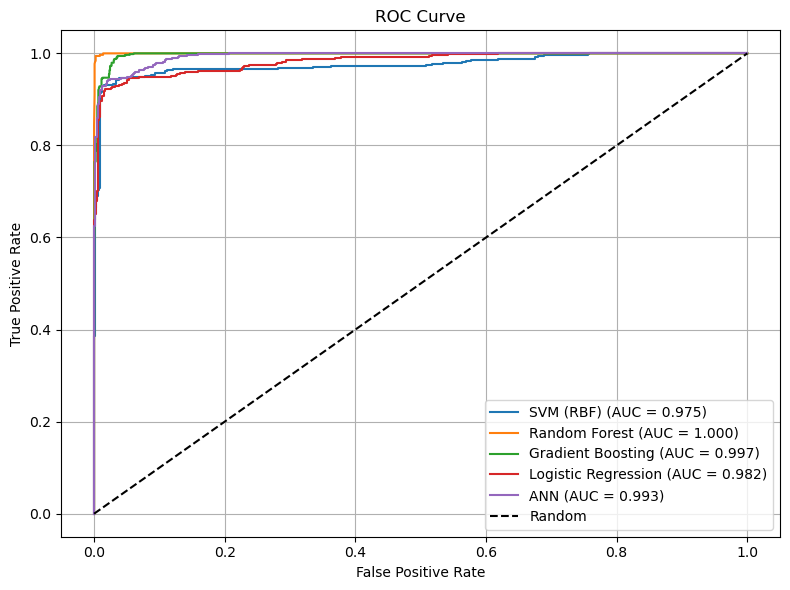

In [13]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, classification_report
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

# =======================
# 数据准备
# =======================
# 合并特征和标签
data_combined = np.hstack([X_total, y_total.reshape(-1, 1)])
X = data_combined[:, 0:3]
y = data_combined[:, -1]

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# 标准化
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

# =======================
# 定义模型
# =======================
model_dict  = {
    "SVM (RBF)": SVC(kernel='rbf', C=1.0, gamma='scale', probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "Logistic Regression": LogisticRegression()
}

# =======================
# 模型评估函数
# =======================
def evaluate_model(name, model, X_test, y_test, y_pred, y_proba):
    print(f"\n📌 [{name}]")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, digits=4))
    
    # AUC 分数
    auc = roc_auc_score(y_test, y_proba)
    print(f"AUC = {auc:.4f}")
    
    # 绘制 ROC 曲线
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

# =======================
# 评估传统模型
# =======================
plt.figure(figsize=(8, 6))
for name, model in model_dict.items():
    model.fit(X_train_std, y_train)
    y_pred = model.predict(X_test_std)
    y_proba = model.predict_proba(X_test_std)[:, 1]
    evaluate_model(name, model, X_test_std, y_test, y_pred, y_proba)

# =======================
# 评估 ANN 模型
# =======================
ann = models.Sequential([
    layers.Input(shape=(X_train_std.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
ann.fit(X_train_std, y_train, epochs=30, batch_size=32, verbose=0)

y_proba_ann = ann.predict(X_test_std).flatten()
y_pred_ann = (y_proba_ann >= 0.5).astype(int)
evaluate_model("ANN", ann, X_test_std, y_test, y_pred_ann, y_proba_ann)

# =======================
# ROC 曲线展示
# =======================
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 873us/step


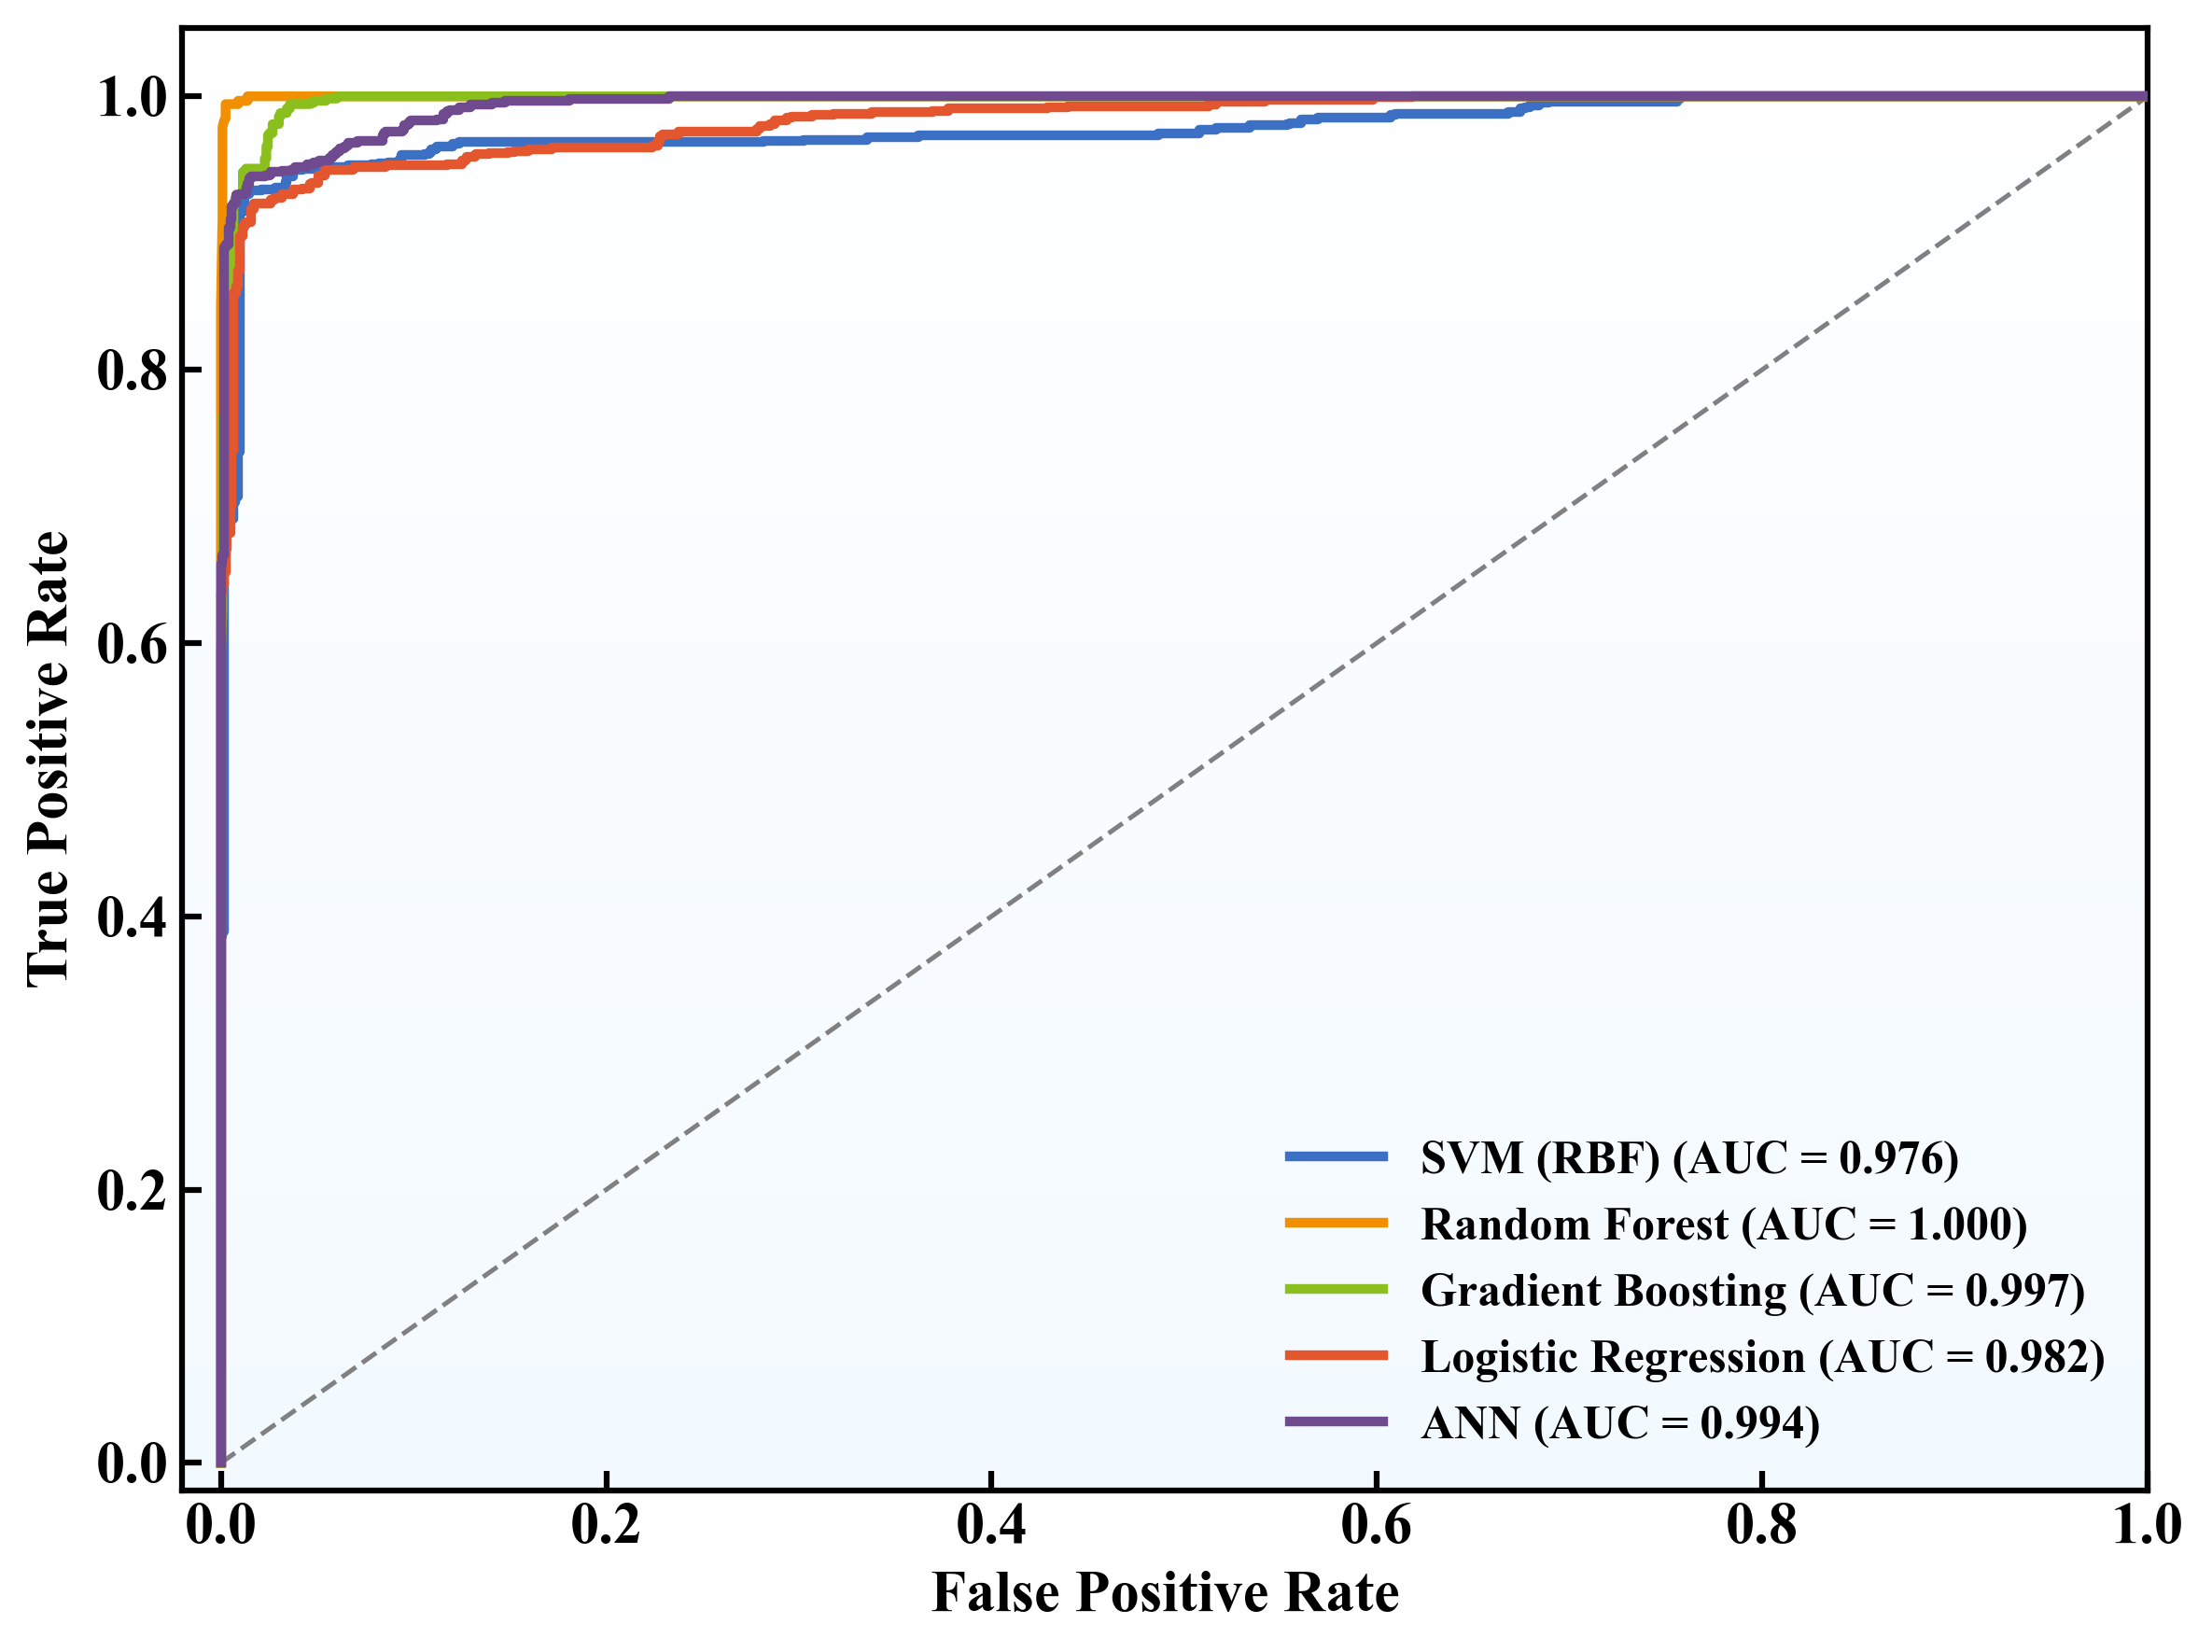

In [16]:

plt.rc('font', family='Times New Roman')
plt.rcParams.update({
    'font.weight': 'bold',
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.major.size': 5,
    'ytick.major.size': 5,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15,
})
# =======================
color_map = {
    "SVM (RBF)": "#3B70C4",
    "Random Forest": "#F18F01",
    "Gradient Boosting": "#8ABF1D",
    "Logistic Regression": "#E4572E",
    "ANN": "#6F4A8E"
}

# =======================
# ROC 曲线批量绘制
# =======================
plt.figure(figsize=(8, 6), dpi=300)

# 背景渐变
gradient = np.linspace(1, 0.4, 256).reshape(-1, 1)
bg_cmap = LinearSegmentedColormap.from_list("bg", ["#F3FAFF", "#FFFFFF"])
plt.imshow(gradient, aspect='auto', extent=[-0.02, 1, -0.02, 1.05], cmap=bg_cmap, alpha=1, zorder=0)

for name, model in model_dict.items():
    model.fit(X_train_std, y_train)
    y_pred = model.predict(X_test_std)
    y_proba = model.predict_proba(X_test_std)[:, 1]

    auc_val = roc_auc_score(y_test, y_proba)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, color=color_map[name], lw=2.5,
             label=f"{name} (AUC = {auc_val:.3f})", zorder=3)

# ANN 模型
ann = models.Sequential([
    layers.Input(shape=(X_train_std.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
ann.fit(X_train_std, y_train, epochs=30, batch_size=32, verbose=0)

y_proba_ann = ann.predict(X_test_std).flatten()
auc_ann = roc_auc_score(y_test, y_proba_ann)
fpr_ann, tpr_ann, _ = roc_curve(y_test, y_proba_ann)
plt.plot(fpr_ann, tpr_ann, color=color_map["ANN"], lw=2.5,
         label=f"ANN (AUC = {auc_ann:.3f})", zorder=3)

# 随机参考线
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', lw=1.2, zorder=2)

# 轴与标题
plt.xlim([-0.02, 1.0])
plt.ylim([-0.02, 1.05])
plt.xlabel('False Positive Rate', fontsize=15, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=15, fontweight='bold')

plt.legend(loc='lower right', fontsize=12, frameon=False)
plt.grid(False)

# 边框加粗
for spine in plt.gca().spines.values():
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()


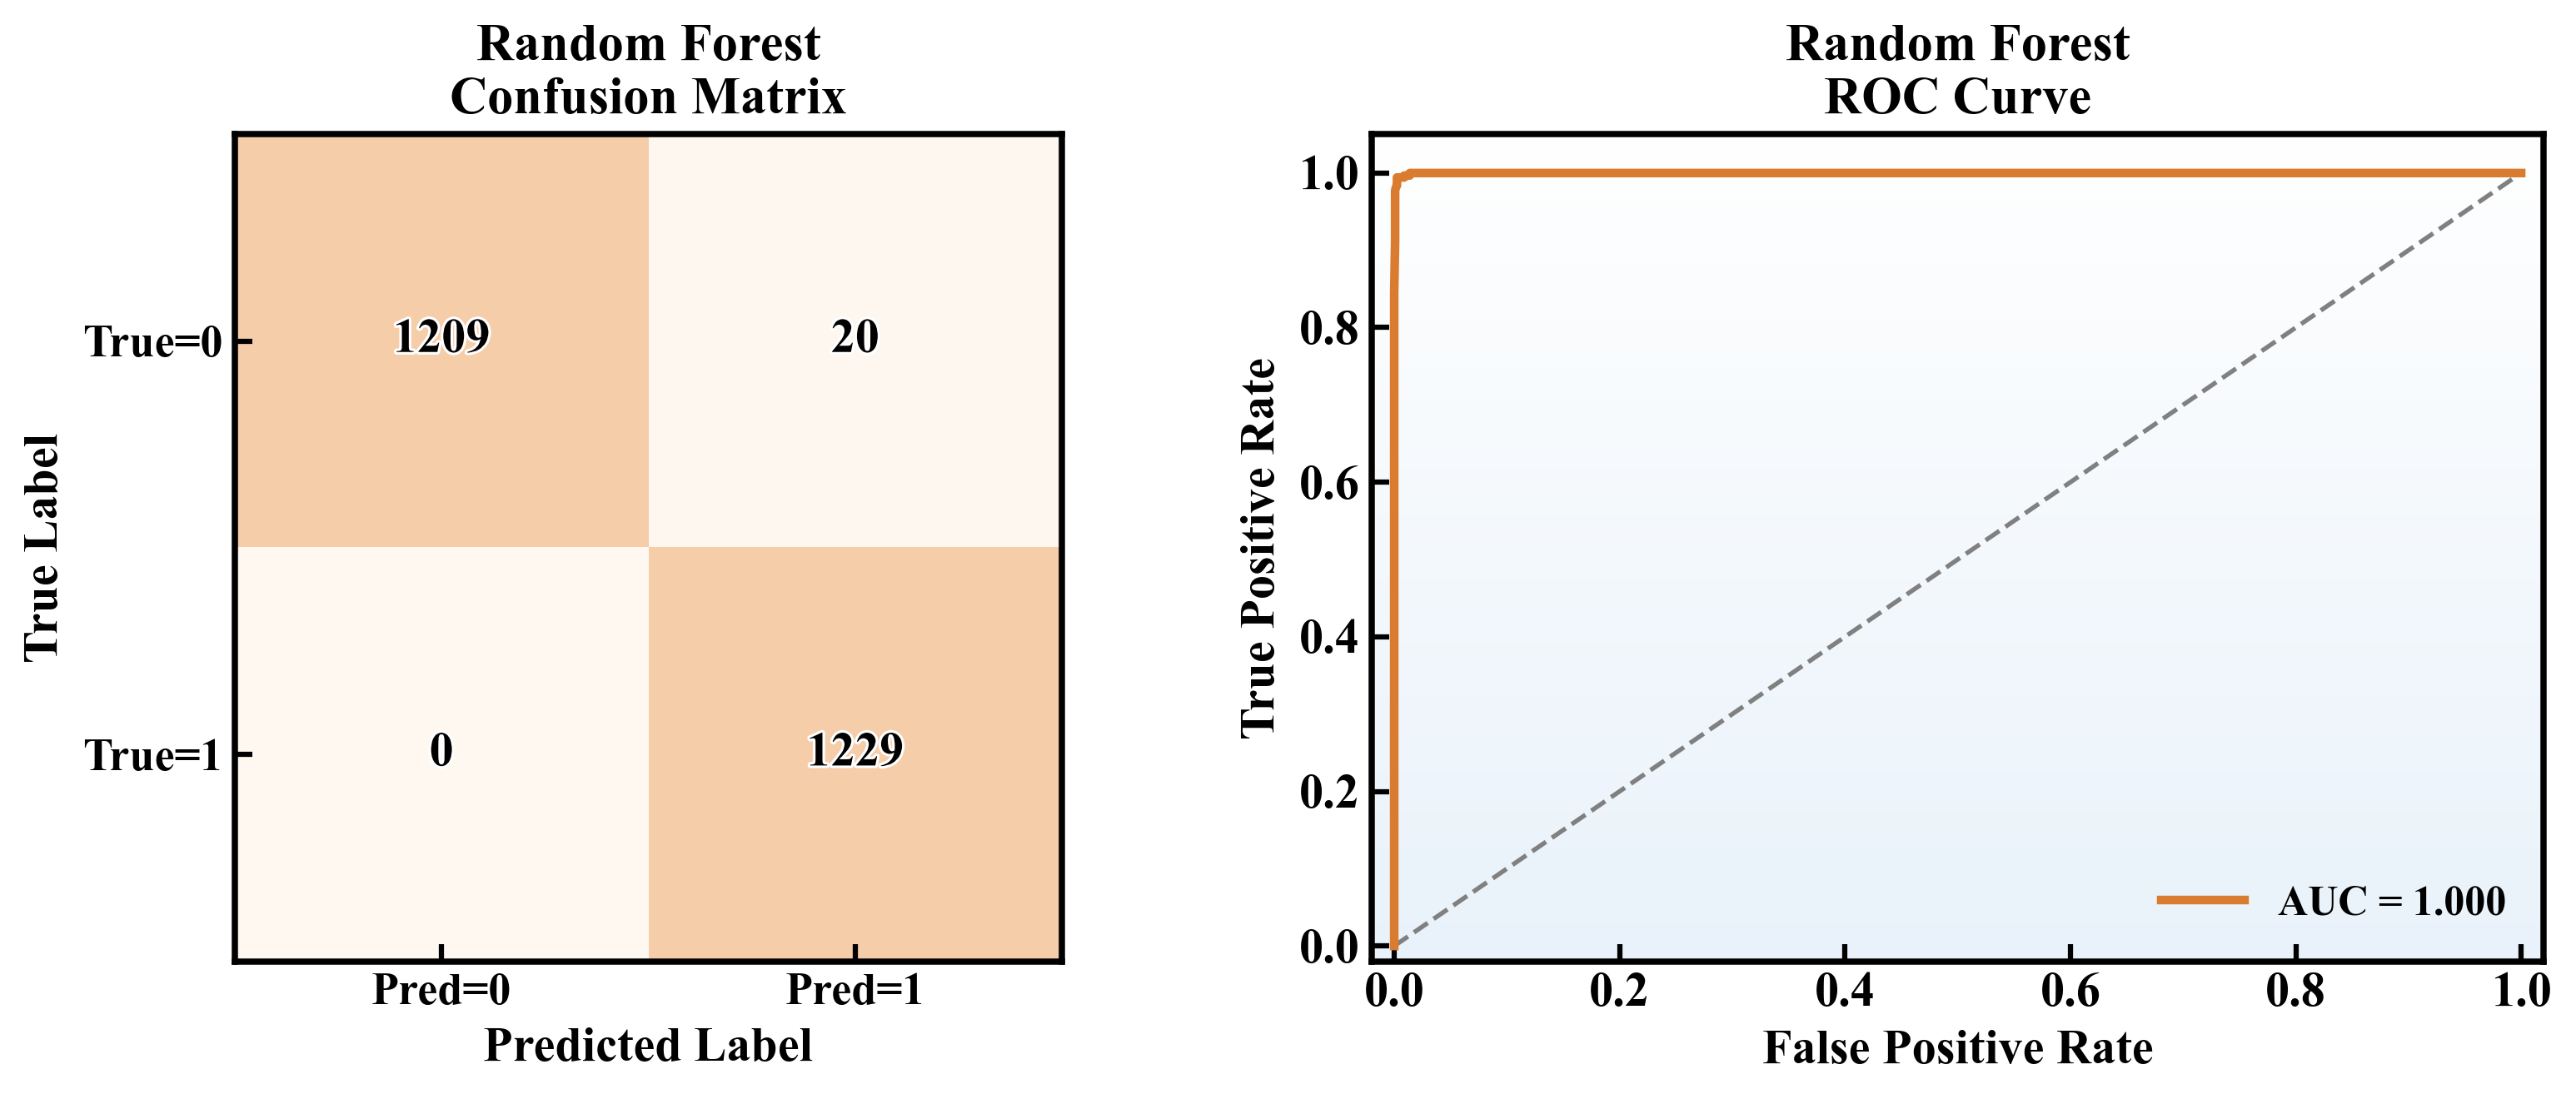

In [17]:
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patheffects as path_effects

# =======================
# 训练 RF 模型
# =======================
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_std, y_train)

# 预测结果
y_pred_rf = rf_model.predict(X_test_std)
y_proba_rf = rf_model.predict_proba(X_test_std)[:, 1]

# 混淆矩阵 & ROC 计算
cm = confusion_matrix(y_test, y_pred_rf)
fpr, tpr, _ = roc_curve(y_test, y_proba_rf)
auc_val = roc_auc_score(y_test, y_proba_rf)

# =======================
# 绘图风格
# =======================
plt.rc('font', family='Times New Roman')
plt.rcParams.update({
    'font.weight': 'bold',
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.width': 1.8,
    'ytick.major.width': 1.8,
    'xtick.major.size': 5,
    'ytick.major.size': 5,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
})
fig, axs = plt.subplots(1, 2, figsize=(11, 4.5), dpi=300)

# === 左侧混淆矩阵 ===
cmap_cm = LinearSegmentedColormap.from_list("cm_soft_orange", ["#FFF8F0", "#F6C89F"])  # 奶油浅橙
roc_bg_cmap = LinearSegmentedColormap.from_list("bg_warm", ["#FFFDF8", "#FAF3E0"])  # 浅米白到暖灰
im = axs[0].imshow(cm, cmap=cmap_cm, extent=(0, 2, 2, 0), alpha=0.9)

for i in range(2):
    for j in range(2):
        txt = axs[0].text(j + 0.5, i + 0.5, f'{cm[i, j]}', ha='center', va='center',
                          fontsize=14, fontweight='bold', color='black')
        txt.set_path_effects([path_effects.Stroke(linewidth=1.5, foreground='white'),
                              path_effects.Normal()])

axs[0].set_title("Random Forest\nConfusion Matrix", fontsize=15, fontweight='bold')
axs[0].set_xticks([0.5, 1.5])
axs[0].set_xticklabels(['Pred=0', 'Pred=1'], fontsize=13)
axs[0].set_yticks([0.5, 1.5])
axs[0].set_yticklabels(['True=0', 'True=1'], fontsize=13)
axs[0].set_xlabel('Predicted Label', fontsize=14, fontweight='bold')
axs[0].set_ylabel('True Label', fontsize=14, fontweight='bold')
axs[0].tick_params(width=1.5)

# === 右侧 ROC 曲线 ===
gradient = np.linspace(1, 0.4, 256).reshape(-1, 1)
bg_cmap = LinearSegmentedColormap.from_list("bg", ["#E9F2FA", "#FFFFFF"])
axs[1].imshow(gradient, aspect='auto', extent=[-0.02, 1.02, -0.02, 1.05],
              cmap=bg_cmap, alpha=1, zorder=0)

axs[1].plot(fpr, tpr, color="#D97C30", lw=2.5,
            label=f'AUC = {auc_val:.3f}', zorder=3)
axs[1].plot([0, 1], [0, 1], linestyle='--', color='gray', lw=1.3, zorder=2)

axs[1].set_xlim([-0.02, 1.02])
axs[1].set_ylim([-0.02, 1.05])
axs[1].set_xlabel('False Positive Rate', fontsize=14, fontweight='bold')
axs[1].set_ylabel('True Positive Rate', fontsize=14, fontweight='bold')
axs[1].set_title("Random Forest\nROC Curve", fontsize=15, fontweight='bold')
axs[1].legend(loc='lower right', fontsize=12, frameon=False)
axs[1].tick_params(width=1.5)
# 边框加粗
for ax in axs:
    for spine in ax.spines.values():
        spine.set_linewidth(1.8)
# 布局优化
plt.subplots_adjust(wspace=0.3)
plt.tight_layout()
plt.show()


In [20]:
from sklearn.preprocessing import StandardScaler
import joblib

# 1. 初始化并拟合训练集
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

# 2. 保存 scaler 到文件
joblib.dump(scaler, 'scaler_Nb.pkl')

# 3. 训练模型（以RF为例）
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_std, y_train)

# 4. 保存模型
joblib.dump(rf, 'rf_model_Nb.pkl')

['rf_model_Nb.pkl']

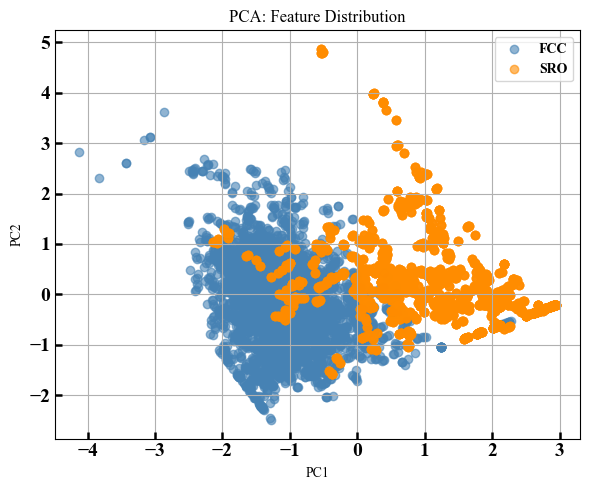

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# 假设你已有这两个变量
# X_total: shape = (n_samples, n_features)
# y_total: shape = (n_samples,), 取值为 0 (FCC) 或 1 (SRO)

# 标准化特征
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_total)

# 1️⃣ PCA 可视化
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6, 5))
plt.scatter(X_pca[y_total == 0, 0], X_pca[y_total == 0, 1], label="BCC", alpha=0.6, c='steelblue')
plt.scatter(X_pca[y_total == 1, 0], X_pca[y_total == 1, 1], label="SRO", alpha=0.6, c='darkorange')
plt.title("PCA: Feature Distribution")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

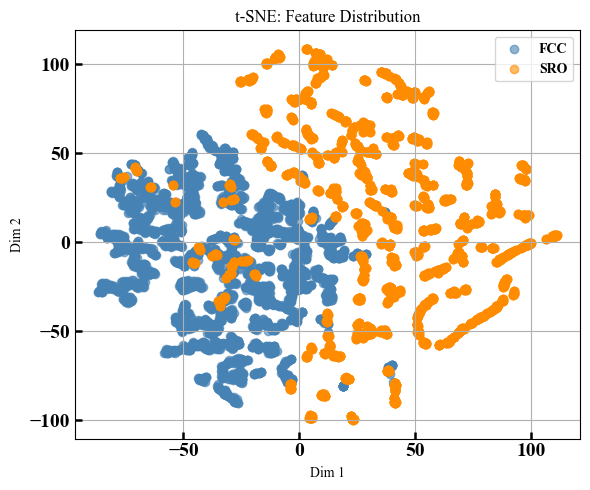

In [22]:
# 2️⃣ t-SNE 可视化
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(6, 5))
plt.scatter(X_tsne[y_total == 0, 0], X_tsne[y_total == 0, 1], label="BCC", alpha=0.6, c='steelblue')
plt.scatter(X_tsne[y_total == 1, 0], X_tsne[y_total == 1, 1], label="SRO", alpha=0.6, c='darkorange')
plt.title("t-SNE: Feature Distribution")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

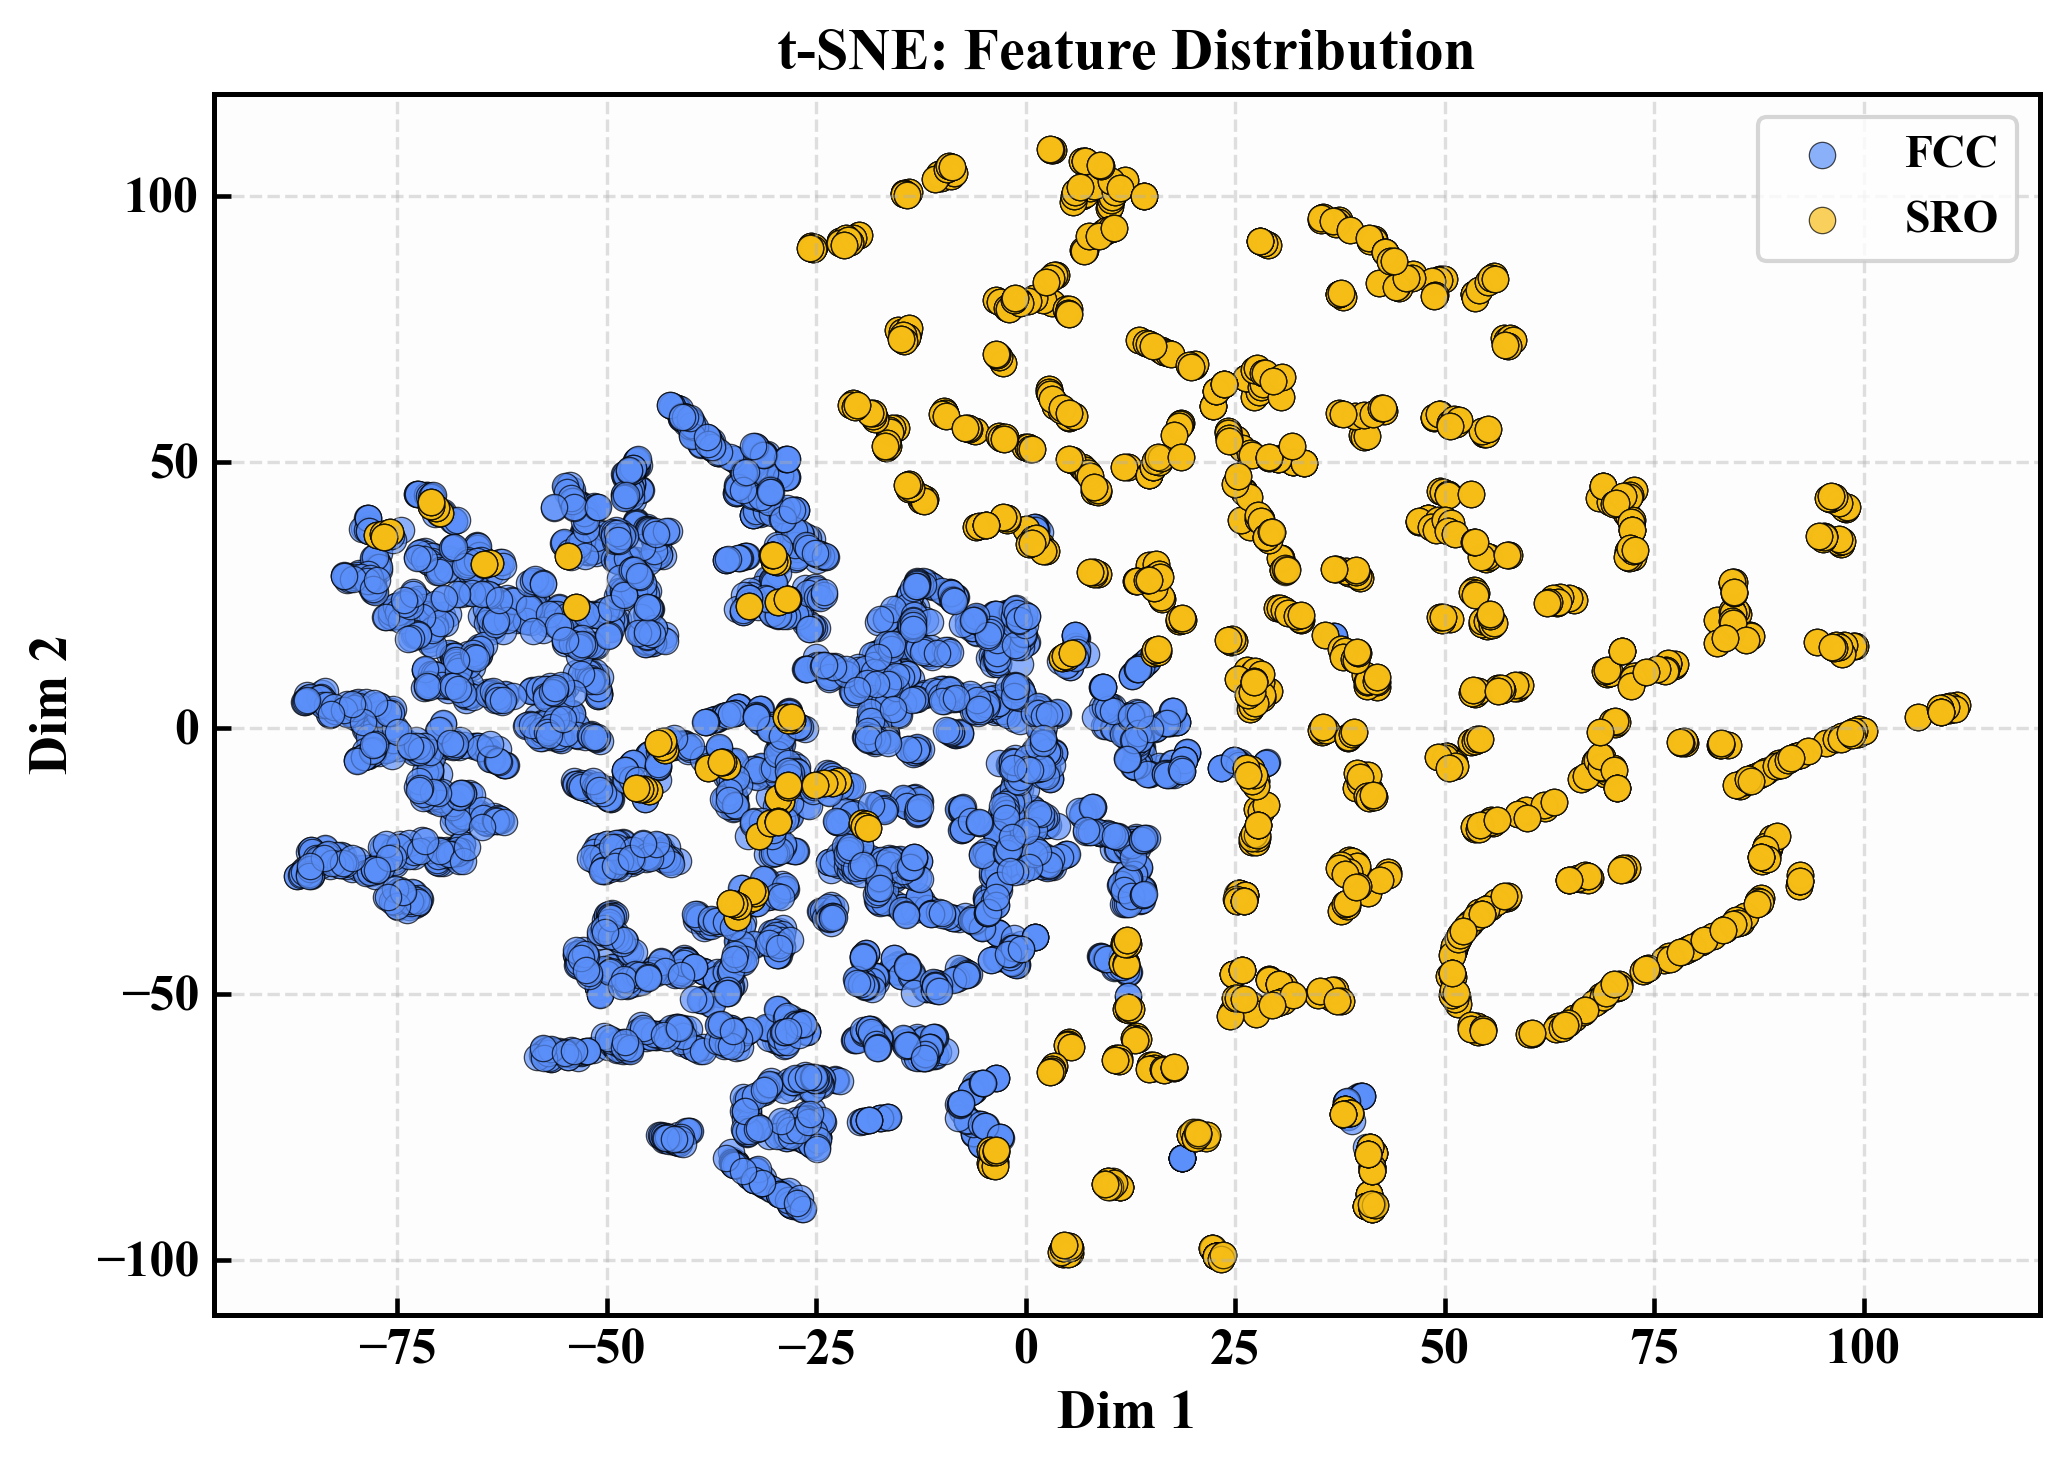

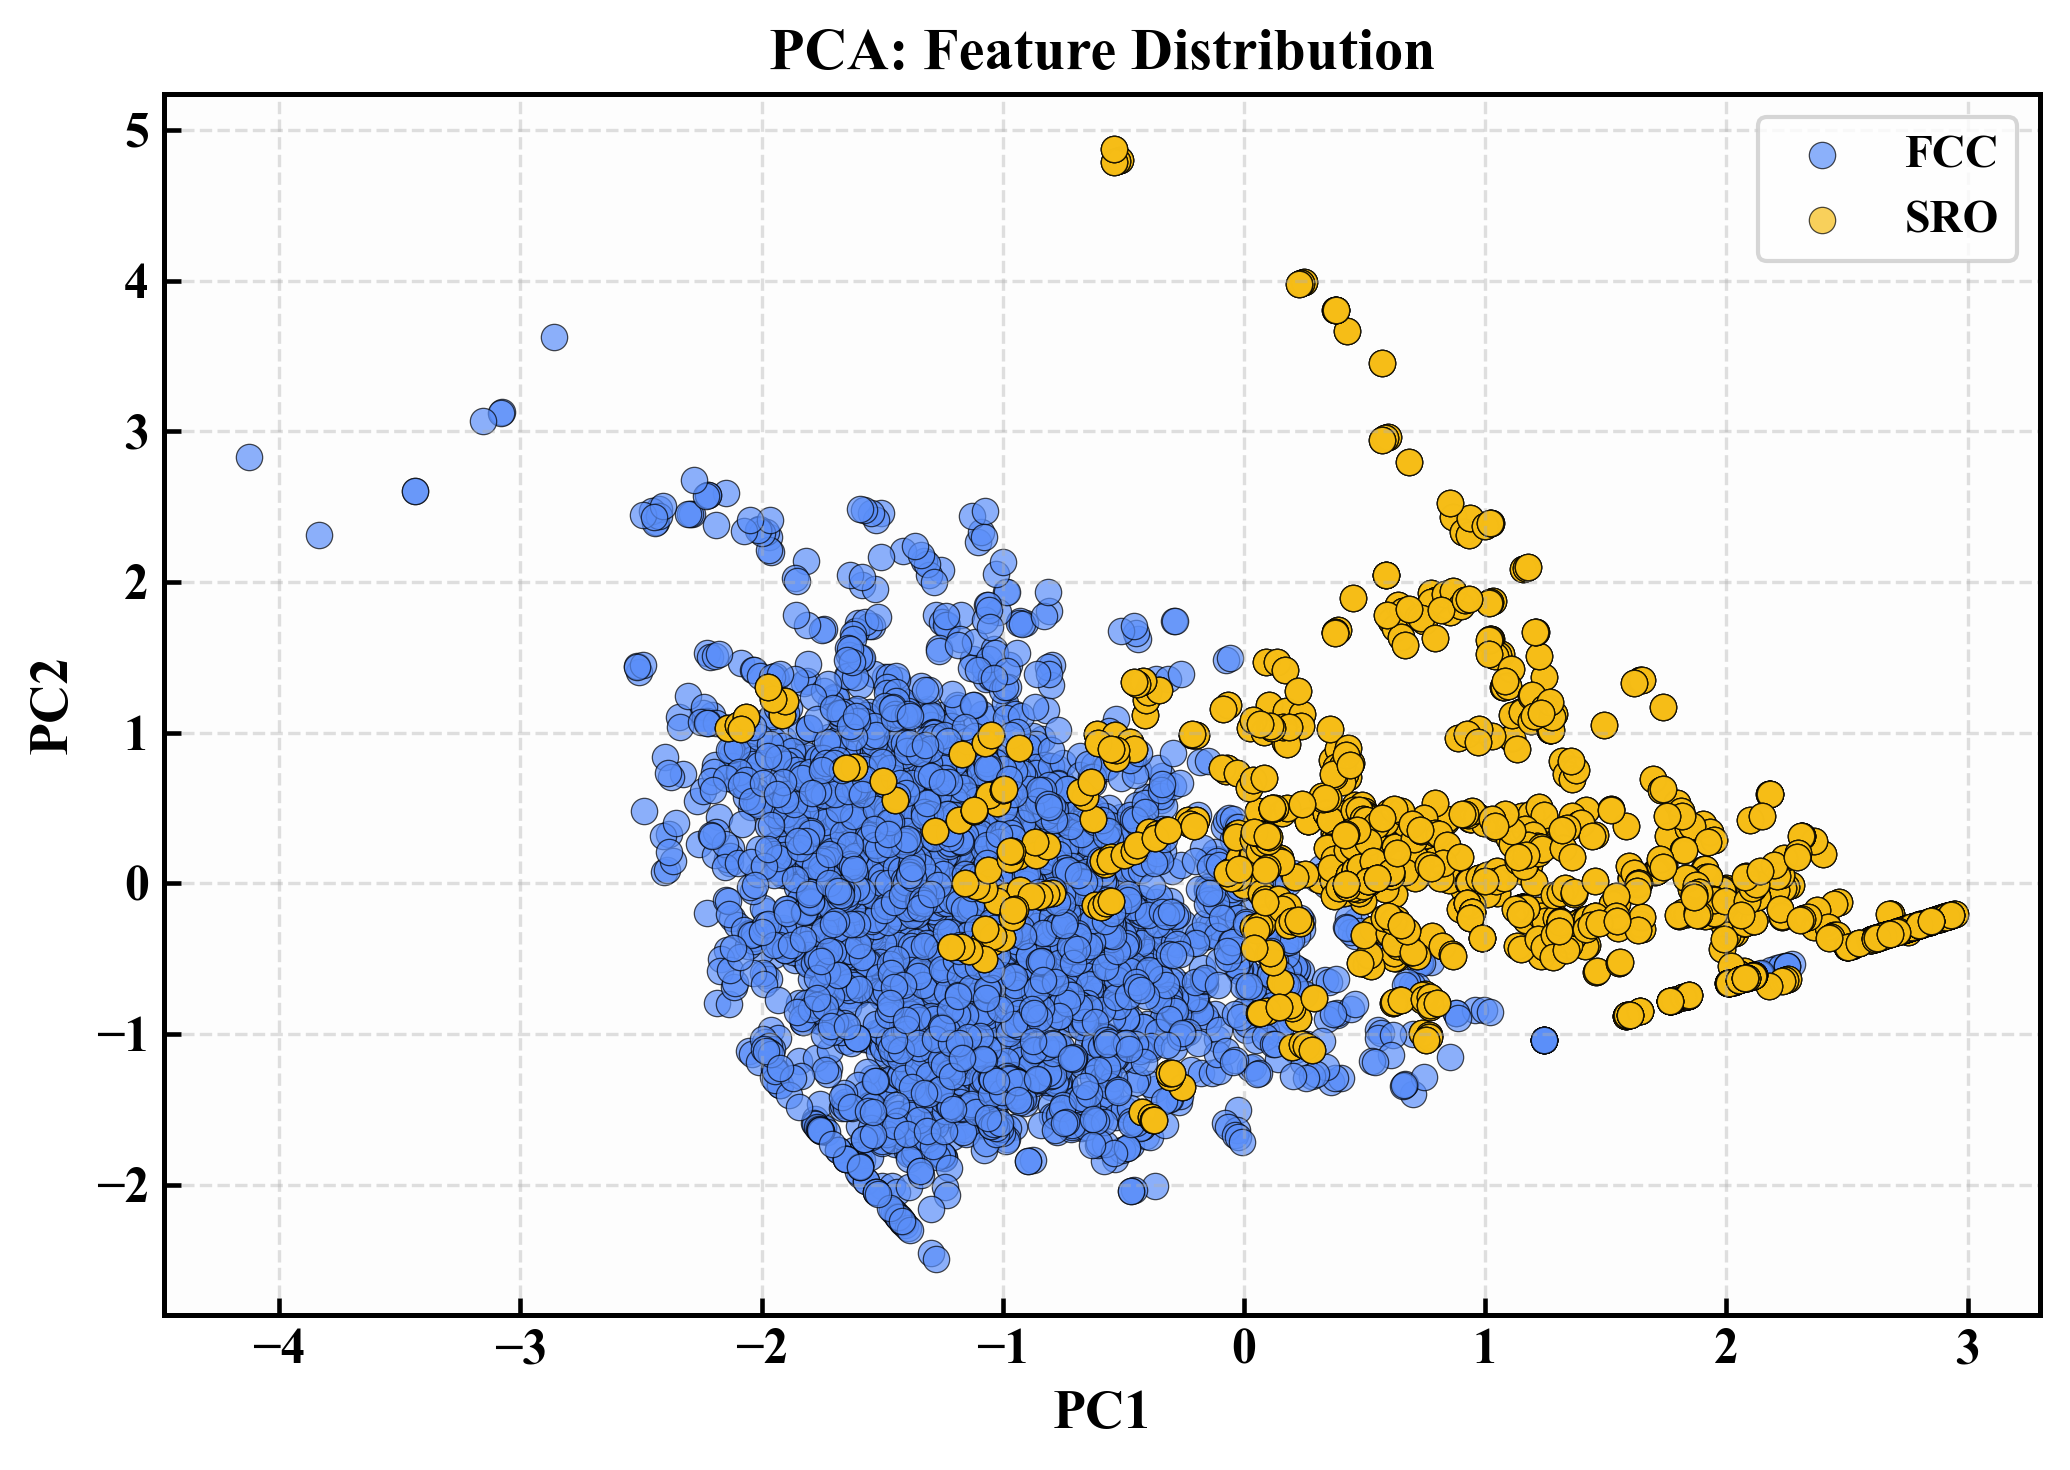

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# 设置全局绘图风格
plt.rc('font', family='Times New Roman')
plt.rcParams.update({
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.linewidth': 1.2,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'xtick.major.width': 1.1,
    'ytick.major.width': 1.1,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12
})

# 自定义颜色
color_fcc = '#5B8FF9'       # 温和蓝
color_sro = '#F6BD16'       # 清新橙

# t-SNE 图
fig, ax = plt.subplots(figsize=(7, 5), dpi=300)
ax.set_facecolor("#fdfdfd")

ax.scatter(X_tsne[y_total == 0, 0], X_tsne[y_total == 0, 1],
           label="BCC", alpha=0.7, c=color_fcc, edgecolors='k', linewidths=0.3, s=40)
ax.scatter(X_tsne[y_total == 1, 0], X_tsne[y_total == 1, 1],
           label="SRO", alpha=0.7, c=color_sro, edgecolors='k', linewidths=0.3, s=40)

ax.set_title("t-SNE: Feature Distribution", fontsize=14, fontweight='bold')
ax.set_xlabel("Dim 1", fontsize=13, fontweight='bold')
ax.set_ylabel("Dim 2", fontsize=13, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(fontsize=11, loc='best', frameon=True)
plt.tight_layout()
plt.show()

# PCA 图
fig, ax = plt.subplots(figsize=(7, 5), dpi=300)
ax.set_facecolor("#fdfdfd")

ax.scatter(X_pca[y_total == 0, 0], X_pca[y_total == 0, 1],
           label="FCC", alpha=0.7, c=color_fcc, edgecolors='k', linewidths=0.3, s=40)
ax.scatter(X_pca[y_total == 1, 0], X_pca[y_total == 1, 1],
           label="SRO", alpha=0.7, c=color_sro, edgecolors='k', linewidths=0.3, s=40)

ax.set_title("PCA: Feature Distribution", fontsize=14, fontweight='bold')
ax.set_xlabel("PC1", fontsize=13, fontweight='bold')
ax.set_ylabel("PC2", fontsize=13, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(fontsize=11, loc='best', frameon=True)
plt.tight_layout()
plt.show()
